In [87]:
from pyparsing import withClass
from sympy.printing.pytorch import torch

from signature.expected_signature import expected_bm_fm_signature
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv
import signature.tensor_algebra as ta
from simulation.diffusion import Diffusion

PALETTE = ["#4E7268", "#C0714A", "#C9A84C", "#7A9E7E", "#8B5A6B", "#4A5568"]
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=PALETTE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [158]:
n_t_grid = 20_001
t_grid = np.linspace(0, 4, n_t_grid)

burn_in_idx = n_t_grid // 2 * 0
cp_idx = int(burn_in_idx + 0.5 * (n_t_grid - burn_in_idx))

rng = np.random.default_rng(seed=4)
diffusion = Diffusion(t_grid=t_grid, size=1, dim=1, rng=rng)

mu_1 = 500
mu_2 = 50

sigma_1 = np.sqrt(2 * mu_1)
sigma_2 = np.sqrt(2 * mu_2)

ou_1 = diffusion.ornstein_uhlenbeck(lam=mu_1, sigma=sigma_1, squeeze=True)
ou_2 = diffusion.ornstein_uhlenbeck(lam=mu_2, sigma=sigma_2, squeeze=True)

signal = np.zeros_like(ou_1)
signal[:cp_idx] = ou_1[:cp_idx]
signal[cp_idx:] = ou_2[cp_idx:] + np.exp(-mu_2 * (t_grid[cp_idx:] - t_grid[cp_idx - 1])) * (ou_1[cp_idx - 1] - ou_2[cp_idx - 1])

0 8000


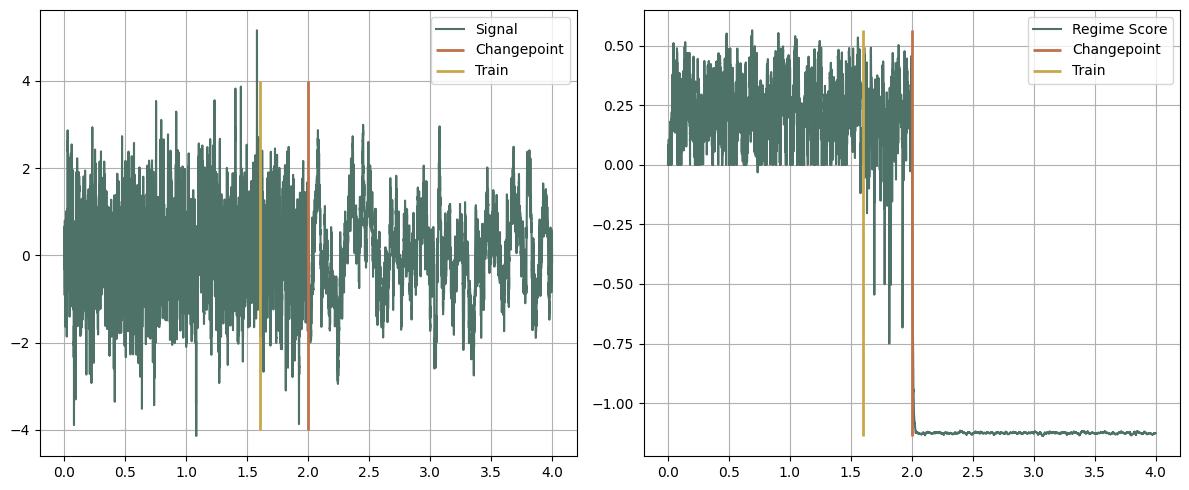

In [9]:
from sklearn.svm import OneClassSVM

train_idx = int(burn_in_idx + (n_t_grid - burn_in_idx) * 0.4)

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
path = np.vstack((t_grid, t_grid, signal, np.cumsum(np.diff(signal, prepend=signal[0:1])**2))).T

trunc = 3
lam = 100

transformer = EFMSignatureTransform(trunc=trunc, lam=lam)
pipe = Pipeline([
    ('sig', transformer),
    ('scaler', StandardScaler()),
])
pipe.fit(path[:train_idx])
efm_sig = pipe.transform(path)

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='rbf', nu=0.01, gamma=0.04)

# 2. Learn the reference regime (find theta and rho)
print(burn_in_idx, train_idx)
model.fit(X=efm_sig[burn_in_idx:train_idx])
# 4. Use the model as your functional F(S_t)
# For a new signature S_t:

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score = model.decision_function(efm_sig[burn_in_idx:])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(t_grid[burn_in_idx:] - t_grid[burn_in_idx], signal[burn_in_idx:], label="Signal")
ax[0].vlines(t_grid[cp_idx] - t_grid[burn_in_idx], ymin=-4, ymax=4, linestyles='-', color=PALETTE[1], lw=2, label="Changepoint")
ax[0].vlines(t_grid[train_idx] - t_grid[burn_in_idx], ymin=-4, ymax=4, linestyles='-', color=PALETTE[2], lw=2, label="Train")
ax[0].legend()

ax[1].plot(t_grid[burn_in_idx:] - t_grid[burn_in_idx], regime_score, label="Regime Score")
ax[1].vlines(t_grid[cp_idx] - t_grid[burn_in_idx], ymin=np.min(regime_score), ymax=np.max(regime_score), linestyles='-', color=PALETTE[1], lw=2, label="Changepoint")
ax[1].vlines(t_grid[train_idx] - t_grid[burn_in_idx], ymin=np.min(regime_score), ymax=np.max(regime_score), linestyles='-', color=PALETTE[2], lw=2, label="Train")
ax[1].legend()

plt.savefig("images/CPD/cpd_OU.pdf", format="pdf", transparent=True)

In [4]:
# fig, ax = plt.subplots()
# # 1. Create the twin axis for the exponential curves
# ax_twin = ax.twinx()
#
# # 2. Plot the signals on the original (left) y-axis
# line1, = ax.plot(t_grid, signal, color=color_cycle[0], label='Signal')
#
# # 3. Plot the exponential curves on the new (right) y-axis
# # Added linestyle='--' to help distinguish theoretical curves from raw data
# lam_1 = 20
# line3, = ax_twin.plot(t_grid[:cp_idx], lam_1 * np.exp(lam_1 * (t_grid[:cp_idx] - t_grid[cp_idx])),
#                      color=color_cycle[0], linestyle='--', label='Fit 1', lw=3)
# wind = 500 / 5000
# line3, = ax_twin.plot(t_grid[:cp_idx], (t_grid[:cp_idx] <= 1) * (t_grid[:cp_idx] >= 1 - wind) / wind,
#                      color=color_cycle[1], linestyle='--', label='Fit 1', lw=3)
# ax.grid(False)

In [5]:
# # path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
# path = np.vstack((t_grid, t_grid, signal)).T
#
# trunc = 5
#
# fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#
# lam_1 = 4
# path_1 = path.copy()
# path_1[:, 1:] = path_1[:, 1:] * lam_1
# transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
# pipe_1 = Pipeline([
#     ('sig',transformer_1),
#     ('scaler', StandardScaler()),
# ])
#
#
# efm_sig_1 = pipe_1.fit_transform(path_1)
#
# lam_2 = 8
# path_2 = path.copy()
# path_2[:, 1:] = path_2[:, 1:] * lam_2
# transformer_2 = EFMSignatureTransform(trunc=trunc, lam=lam_2)
# pipe_2 = Pipeline([
#     ('sig',transformer_2),
#     ('scaler', StandardScaler()),
# ])
#
# efm_sig_2 = pipe_2.fit_transform(path_2)
#
# sig_idx = ta.word_to_index(word=2, dim=2)
#
# # ax[0].plot(t_grid, efm_sig_1[:, sig_idx], color=color_cycle[0])
# # ax[0].plot(t_grid, efm_sig_2[:, sig_idx], color=color_cycle[1])
# # ax[0].plot(t_grid[:cp_idx], lam_1 * np.exp(lam_1 * (t_grid[:cp_idx] - t_grid[cp_idx])), color=color_cycle[0])
# # ax[0].plot(t_grid[:cp_idx], lam_2 * np.exp(lam_2 * (t_grid[:cp_idx] - t_grid[cp_idx])), color=color_cycle[1])
#
# # 1. Create the twin axis for the exponential curves
# ax_twin = ax[0].twinx()
#
# # 2. Plot the signals on the original (left) y-axis
# line1, = ax[0].plot(t_grid, efm_sig_1[:, sig_idx], color=color_cycle[0], label='Signal 1')
# line2, = ax[0].plot(t_grid, efm_sig_2[:, sig_idx], color=color_cycle[1], label='Signal 2')
#
# # 3. Plot the exponential curves on the new (right) y-axis
# # Added linestyle='--' to help distinguish theoretical curves from raw data
# line3, = ax_twin.plot(t_grid[:cp_idx], lam_1 * np.exp(lam_1 * (t_grid[:cp_idx] - t_grid[cp_idx])),
#                      color=color_cycle[0], linestyle='--', label='Fit 1', lw=3)
# line4, = ax_twin.plot(t_grid[:cp_idx], lam_2 * np.exp(lam_2 * (t_grid[:cp_idx] - t_grid[cp_idx])),
#                      color=color_cycle[1], linestyle='--', label='Fit 2', lw=3)
#
# # 4. Optional: Label the axes to avoid confusion
# ax[0].set_ylabel('Signal Amplitude')
# ax_twin.set_ylabel('Kernel Scale')
#
# # 5. Optional: Coloring the axis ticks/labels to match the data can be helpful
# ax_twin.spines['right'].set_color('gray')
# ax_twin.tick_params(axis='y', colors='gray')
# ax_twin.yaxis.label.set_color('gray')
# ax_twin.grid(False)
#
# ax[1].plot(t_grid, np.sqrt(np.sum((efm_sig_1 - efm_sig_2)**2, axis=1)))
# # ax[1].set_ylim([0, 100000000])

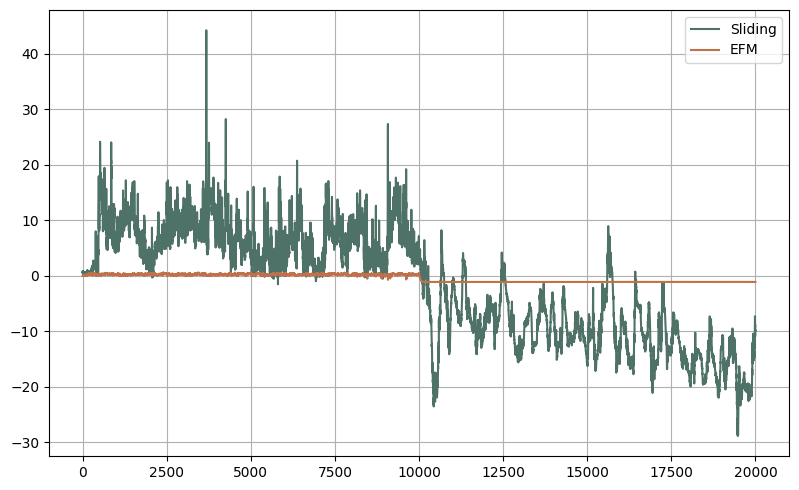

In [6]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
path = np.vstack((t_grid, signal)).T

trunc = 5

window_size = 500
path_1 = path.copy()
transformer_1 = RollingSignatureTransform(trunc=trunc, window_size=window_size)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
model.fit(X=efm_sig_1[:cp_idx - 1000])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score_sliding = model.decision_function(new_S_t)

plt.plot(regime_score_sliding, label="Sliding")
plt.plot(regime_score, label="EFM")
plt.legend()


### TTF Futures

In [8]:
df = pd.read_excel("data/EEX_TTF.xlsx", index_col=0)
df.rename(
    columns={
        "TTF_FUTURE_CALENDAR_PRICE C+1 (EUR/MWh)": "C+1",
        "TTF_FUTURE_CALENDAR_PRICE C+2 (EUR/MWh)": "C+2",
        "TTF_FUTURE_CALENDAR_PRICE C+3 (EUR/MWh)": "C+3",
        "TTF_FUTURE_MONTH_PRICE M+1 (EUR/MWh)": "M+1",
        "TTF_FUTURE_MONTH_PRICE M+2 (EUR/MWh)": "M+2",
        "TTF_FUTURE_MONTH_PRICE M+3 (EUR/MWh)": "M+3",
        "TTF_FUTURE_QUARTER_PRICE Q+1 (EUR/MWh)": "Q+1",
        "TTF_FUTURE_QUARTER_PRICE Q+2 (EUR/MWh)": "Q+2",
        "TTF_FUTURE_QUARTER_PRICE Q+3 (EUR/MWh)": "Q+3",
        "TTF_FUTURE_SEASON_PRICE S+1 (EUR/MWh)": "S+1",
        "TTF_FUTURE_SEASON_PRICE S+2 (EUR/MWh)": "S+2",
    },
    inplace=True
)
df.index = df.index.normalize()
df = df.dropna()

# List of dates to remove (arbitrage)
unwanted_dates = ['2022-03-30', '2022-03-31', '2024-12-31', '2024-12-30', '2021-12-31', '2021-12-30']
# Keep rows where the date is NOT in the unwanted list
df = df[~df.index.isin(unwanted_dates)]

index = df.index
t_grid = np.array((index - index[0]).days / 365)

signal = np.array(df["M+1"]) - np.array(df["C+1"])

/var/folders/mc/53434rwj3q3_5f334ttcrq280000gn/T/ipykernel_1314/551033461.py:24: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df = df[~df.index.isin(unwanted_dates)]


In [9]:
signal.shape

(3286,)

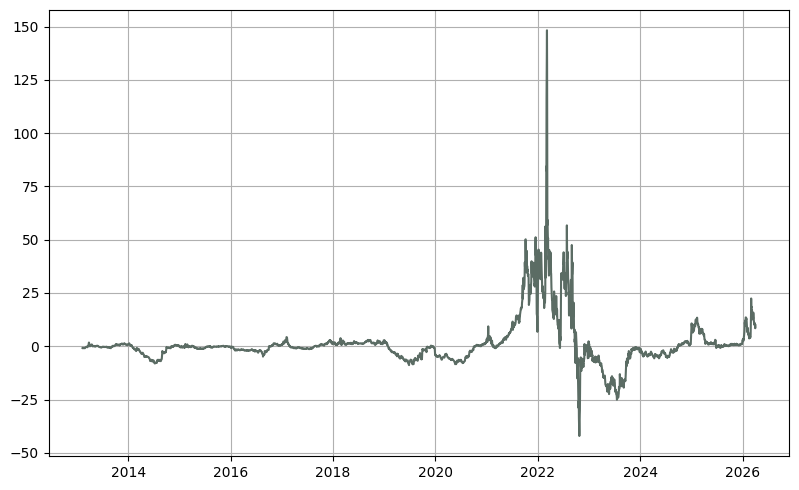

In [10]:
plt.plot(index, signal)

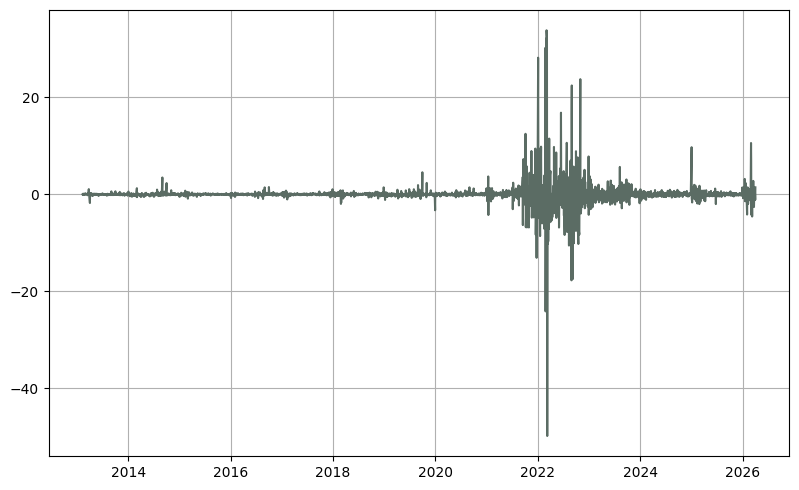

In [11]:
plt.plot(index, np.diff(signal, prepend=signal[0:1]))

(3286,) (3286,)


(-1.0, 1.0)

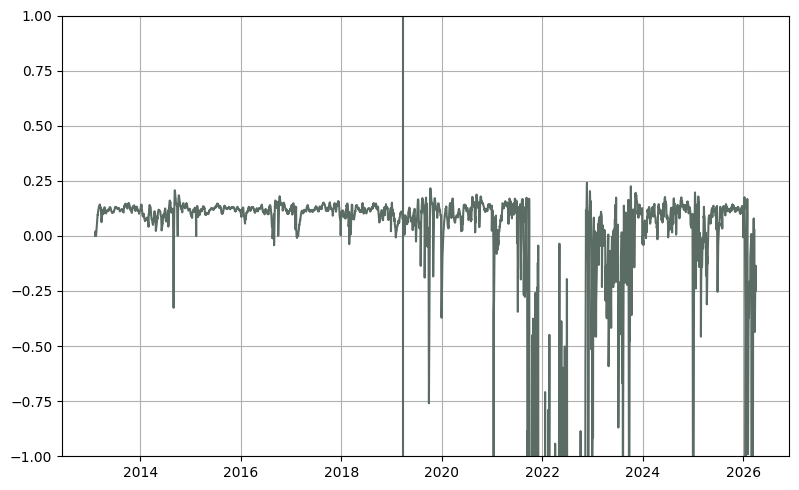

In [13]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
print(t_grid.shape, signal.shape)
path = np.vstack((t_grid, t_grid, signal)).T

trunc = 5
N_train = 1500
lam_1 = 70
path_1 = path.copy()
path_1[:, 1:] = path_1[:, 1:] * lam_1
transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
model.fit(X=efm_sig_1[:N_train])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score = model.decision_function(new_S_t)

plt.plot(index, regime_score)
plt.vlines(index[N_train], -50, 50, label="EFM")
plt.ylim([-1, 1])

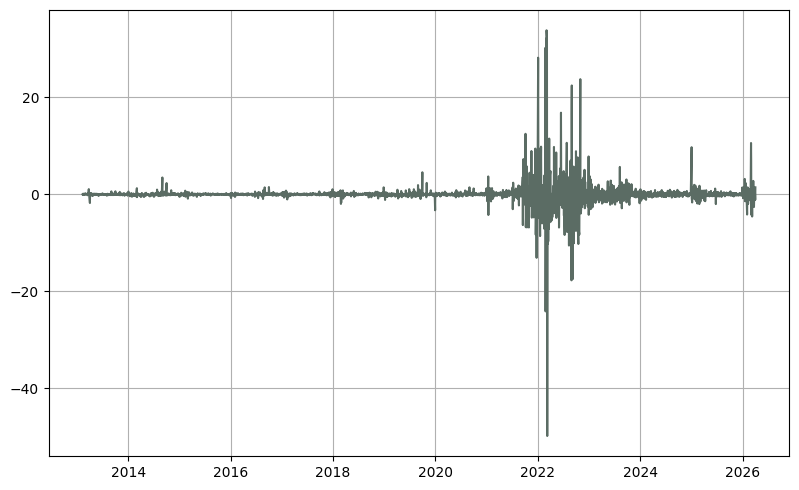

In [14]:
plt.plot(index, np.diff(signal, prepend=signal[0:1]))

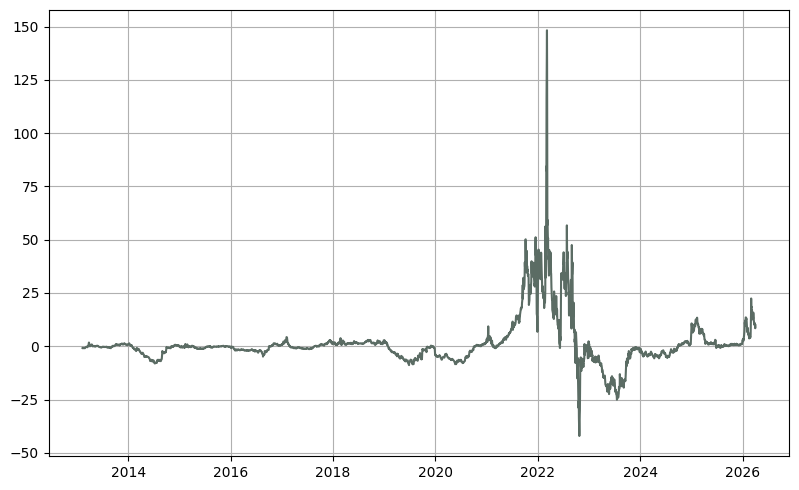

In [15]:
plt.plot(index, signal)

## Regime change in stochastic volatility models

In [16]:
from pricing.models.heston import Heston

In [17]:
stoch_vol_model_before = Heston(theta=0.057, rho=-0.7, lam=2.15, nu=0.86, V0=0.023)

In [18]:
T = 20
N_points = 250 * T
t_grid_before = np.linspace(0, T, N_points)
t_grid_after = np.linspace(T, 2 * T, N_points)

rng = np.random.default_rng(seed=40)
S_before, V_before = stoch_vol_model_before.get_price_trajectory(t_grid=t_grid_before, size=1, F0=100, rng=rng, return_variance=True)
S_before = S_before.squeeze()
V_before = V_before.squeeze()

stoch_vol_model_after = Heston(theta=0.1, rho=-0.4, lam=10, nu=1.5, V0=V_before[-1])
S_after, V_after = stoch_vol_model_after.get_price_trajectory(t_grid=t_grid_after, size=1, F0=S_before[-1], rng=rng, return_variance=True)
S_after = S_after.squeeze()
V_after = V_after.squeeze()

S = np.concatenate([S_before, S_after[1:]])
V = np.concatenate([V_before, V_after[1:]])
t_grid = np.concatenate([t_grid_before, t_grid_after[1:]])

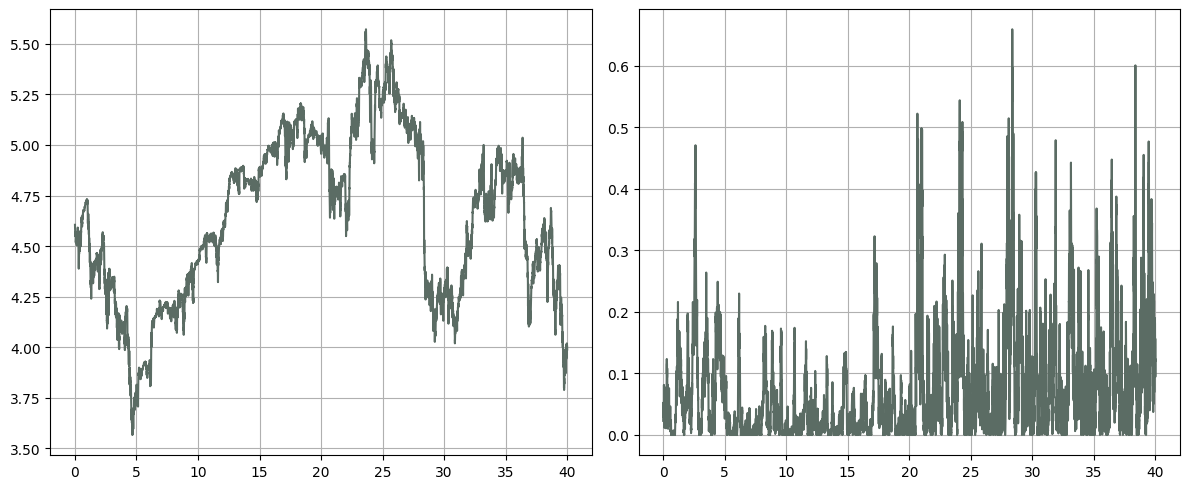

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(t_grid, np.log(S))
ax[1].plot(t_grid, V)

In [20]:
signal = np.log(S)

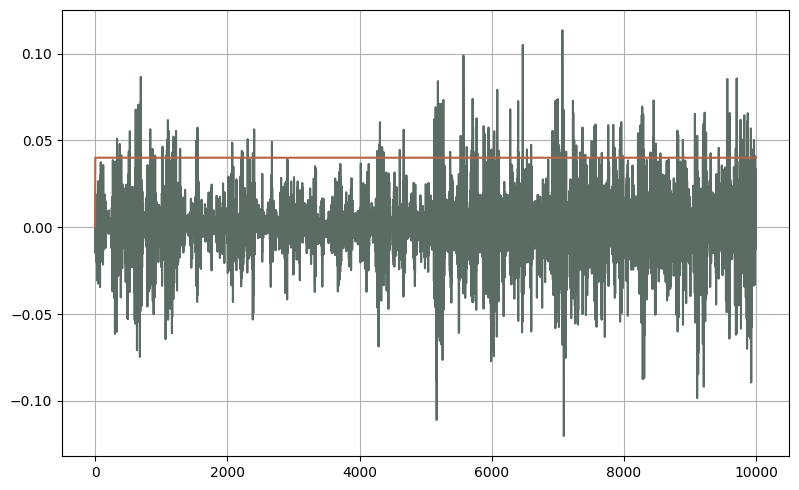

In [21]:
plt.plot(np.diff(signal, prepend=signal[0:1]))
plt.plot(np.diff(t_grid * 10, prepend=t_grid[0:1]))

(9999,) (9999,)


(-0.843074548024207, 0.843074548024207)

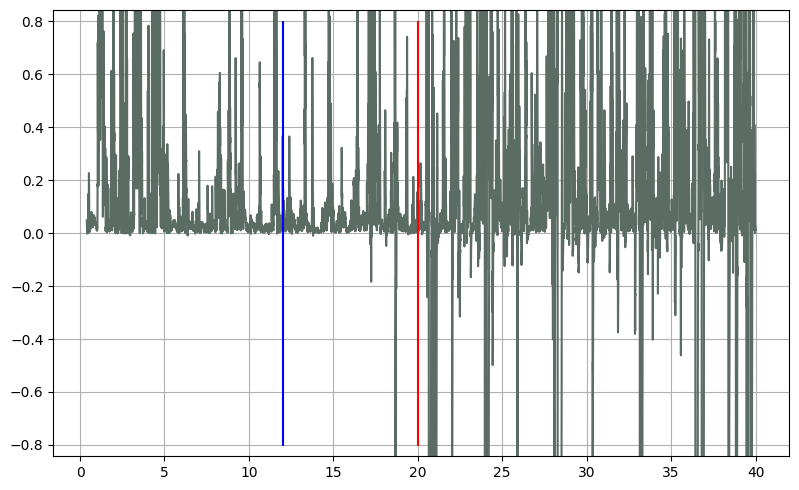

In [22]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
print(t_grid.shape, signal.shape)
path = np.vstack((
    t_grid,
    t_grid * 10,
    signal,
    np.cumsum(np.diff(signal, prepend=signal[0:1])**2)
)).T

trunc = 4
N_train = int(len(t_grid_before) * 0.6)
lam_1 = 24 * 1
path_1 = path.copy()
path_1[:, 1:] = path_1[:, 1:] * lam_1
transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
burn_in = 100
model.fit(X=efm_sig_1[burn_in:N_train])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score = model.decision_function(new_S_t)

plt.plot(t_grid[burn_in:], regime_score[burn_in:])

M = np.percentile(np.abs(regime_score), 90)
plt.vlines(t_grid_before[N_train], -M, M, label="EFM", color="blue")
plt.vlines(t_grid_before[-1], -M, M, label="CP", color="red")
plt.ylim([-1.05 * M, 1.05 * M])

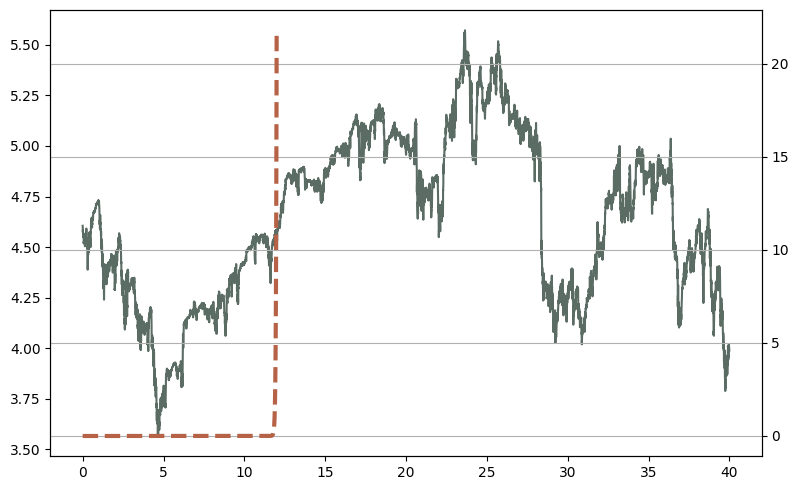

In [23]:
fig, ax = plt.subplots()
# 1. Create the twin axis for the exponential curves
ax_twin = ax.twinx()

# 2. Plot the signals on the original (left) y-axis
line1, = ax.plot(t_grid, signal, color=color_cycle[0], label='Signal')

# 3. Plot the exponential curves on the new (right) y-axis
# Added linestyle='--' to help distinguish theoretical curves from raw data
line3, = ax_twin.plot(t_grid[:N_train], lam_1 * np.exp(lam_1 * (t_grid[:N_train] - t_grid[N_train])),
                     color=color_cycle[1], linestyle='--', label='Fit 1', lw=3)
ax.grid(False)

## Testing Sig-Kernel

NameError: name 'X' is not defined

In [124]:
import torch
import sigkernel

# Specify the static kernel (for linear kernel use sigkernel.LinearKernel())
# static_kernel = sigkernel.RBFKernel(sigma=0.5)
static_kernel = sigkernel.LinearKernel()

# Specify dyadic order for PDE solver (int > 0, default 0, the higher the more accurate but slower)
dyadic_order = 5

# Specify maximum batch size of computation; if memory is a concern try reducing max_batch, default=100
max_batch = 100

# Initialize the corresponding signature kernel
signature_kernel = sigkernel.SigKernel(static_kernel, dyadic_order)

# Synthetic data
batch, len_x, len_y, dim = 5, 10, 20, 2
# Use 'cuda', 'mps', or 'cpu' depending on available hardware
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(41)
X = torch.rand((batch,len_x,dim), dtype=torch.float32, device=device) # shape (batch,len_x,dim)
Y = torch.rand((batch,len_y,dim), dtype=torch.float32, device=device) # shape (batch,len_y,dim)
Z = torch.rand((batch,len_x,dim), dtype=torch.float32, device=device) # shape (batch,len_y,dim)

# Compute signature kernel "batch-wise" (i.e. k(x_1,y_1),...,k(x_batch, y_batch))
K = signature_kernel.compute_kernel(X,Y,max_batch)
print(K)

# Compute signature kernel Gram matrix (i.e. k(x_i,y_j) for i,j=1,...,batch), also works for different batch_x != batch_y)
G = signature_kernel.compute_Gram(X,Y,sym=False,max_batch=max_batch)

# Compute MMD distance between samples x ~ X and samples y ~ Y, where X,Y are two distributions on path space...
mmd = signature_kernel.compute_mmd(X,Y,max_batch)
# ... and to backpropagate through the MMD distance simply call .backward(), like any other PyTorch loss function
# mmd.backward()

# Compute scoring rule between X and a sample path y, i.e. S_sig(X,y) = E[k(X,X)] - 2E[k(X,y] ...
# y = Y[0]
# sr = signature_kernel.compute_scoring_rule(X,y,max_batch)
#
# # ... and expected scoring rule between X and Y, i.e. S(X,Y) = E_Y[S_sig(X,y)]
# esr = signature_kernel.compute_expected_scoring_rule(X,Y,max_batch)
#
# # Sig CHSIC: XY|Z
# sigchsic = signature_kernel.SigCHSIC(X, Y, Z, static_kernel, dyadic_order=1, eps=0.1)

tensor([0.6402, 1.0794, 0.6081, 1.2707, 0.9799], device='mps:0')


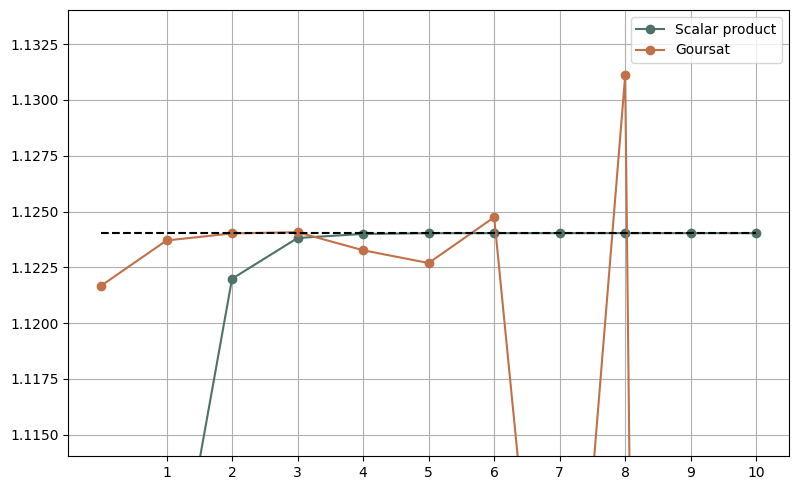

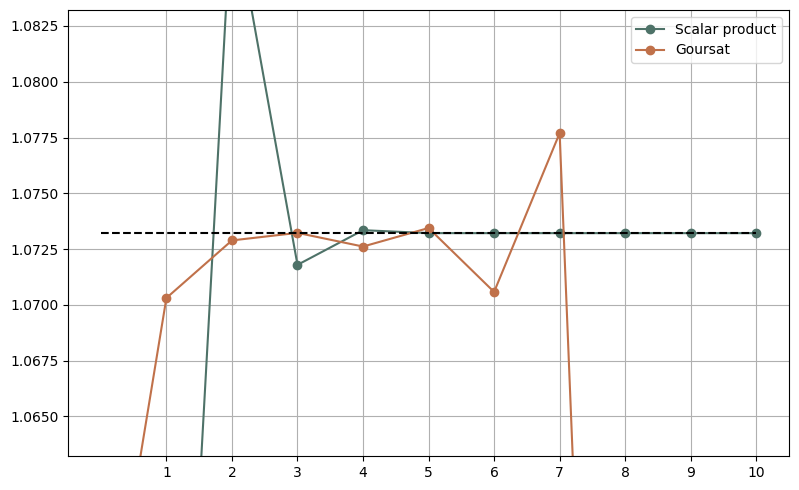

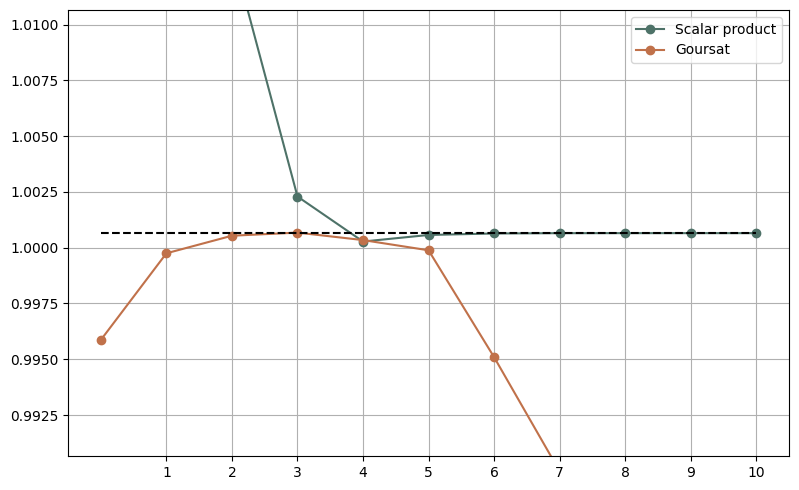

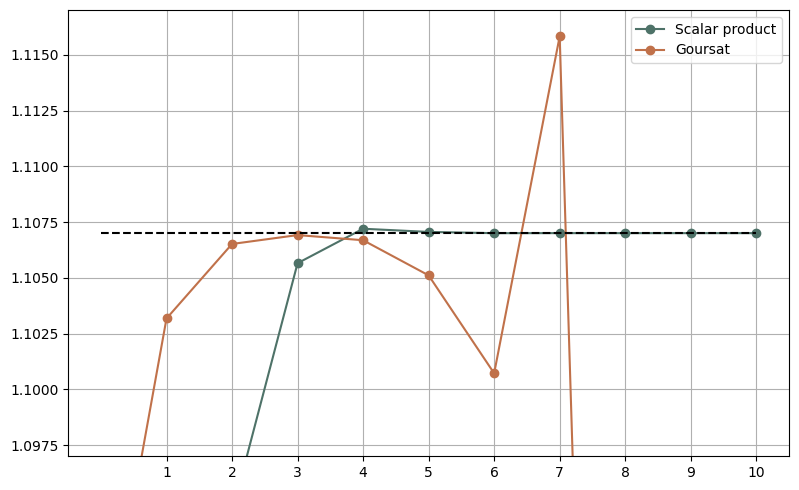

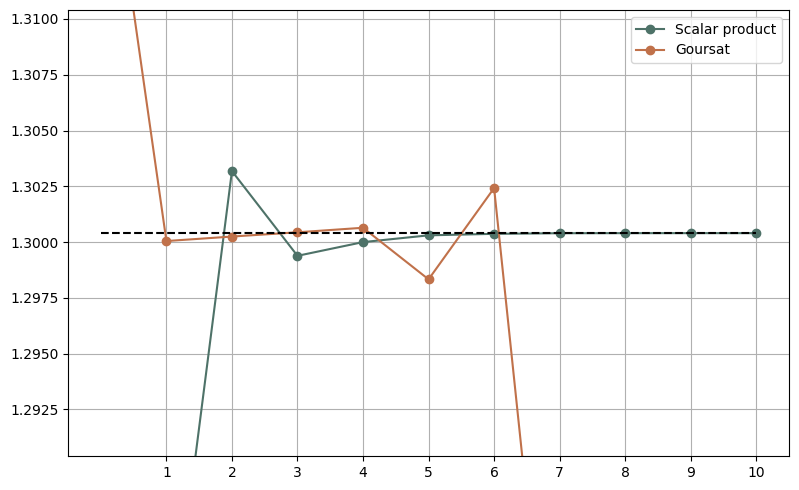

In [152]:
from signature.learning.signature_transform import SignatureTransform

# Simulating paths
# Synthetic data
batch, len_x, len_y, dim = 5, 10, 20, 2
# Use 'cuda', 'mps', or 'cpu' depending on available hardware
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
X = torch.rand((batch,len_x,dim), dtype=torch.float32, device=device) # shape (batch,len_x,dim)
Y = torch.rand((batch,len_y,dim), dtype=torch.float32, device=device) # shape (batch,len_y,dim)


# Linear kernel from signature
transformer = SignatureTransform(trunc=15)

K_scalar_arr = []
K_max_scalar_arr = []
for i in range(batch):
    X_sig = transformer.fit_transform(X.cpu().numpy()[i, :, :])[-1]
    Y_sig = transformer.fit_transform(Y.cpu().numpy()[i, :, :])[-1]

    K_scalar = []
    for trunc in range(1, 11):
        n_max = ta.number_of_words_up_to_trunc(trunc=trunc, dim=2)
        K_scalar.append(X_sig[:n_max] @ Y_sig[:n_max])
    K_scalar_arr.append(K_scalar)
    K_max_scalar_arr.append(X_sig @ Y_sig)

K_scalar_arr = np.array(K_scalar_arr)


# Linear kernel from Goursat's PDE
static_kernel = sigkernel.LinearKernel()

K_arr = []
dyadic_orders = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
for dyadic_order in dyadic_orders:
    # Specify dyadic order for PDE solver (int > 0, default 0, the higher the more accurate but slower)

    # Specify maximum batch size of computation; if memory is a concern try reducing max_batch, default=100
    max_batch = 100

    # Initialize the corresponding signature kernel
    signature_kernel = sigkernel.SigKernel(static_kernel, dyadic_order)

    K = signature_kernel.compute_kernel(X,Y,max_batch)
    K_arr.append(K.cpu().numpy())

K_arr = np.array(K_arr).T


# Convergence
for i in range(batch):
    fig, ax = plt.subplots()
    plt.plot(range(1, 11), K_scalar_arr[i], "o-", label="Scalar product")

    plt.plot(dyadic_orders, K_arr[i], "o-", label="Goursat")

    final_K = K_max_scalar_arr[i]

    plt.hlines(final_K, 0, 10, ls="--", color="k")

    plt.ylim([final_K - 0.01, final_K + 0.01])
    plt.xticks(range(1, 11))
    plt.legend()

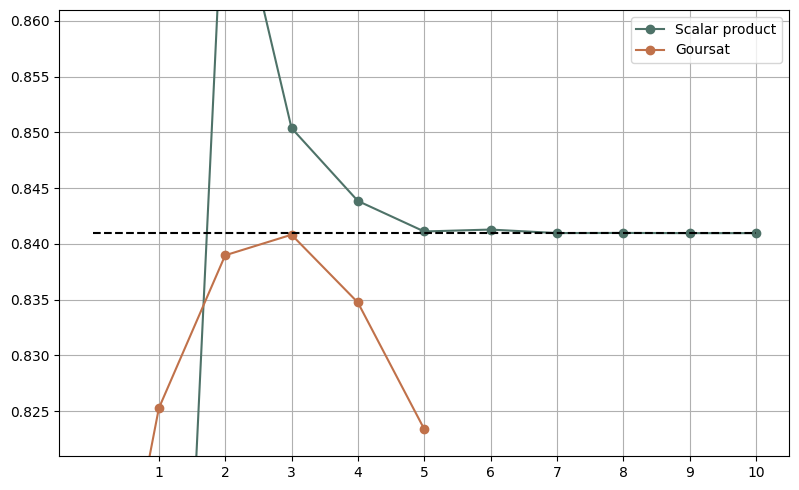

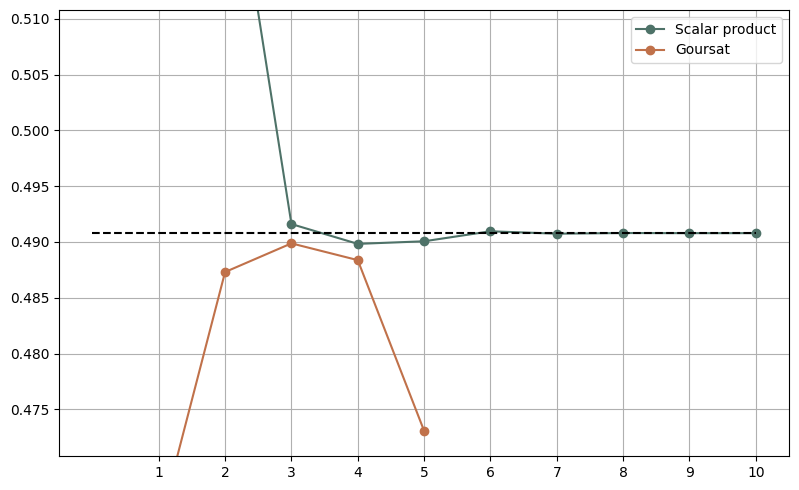

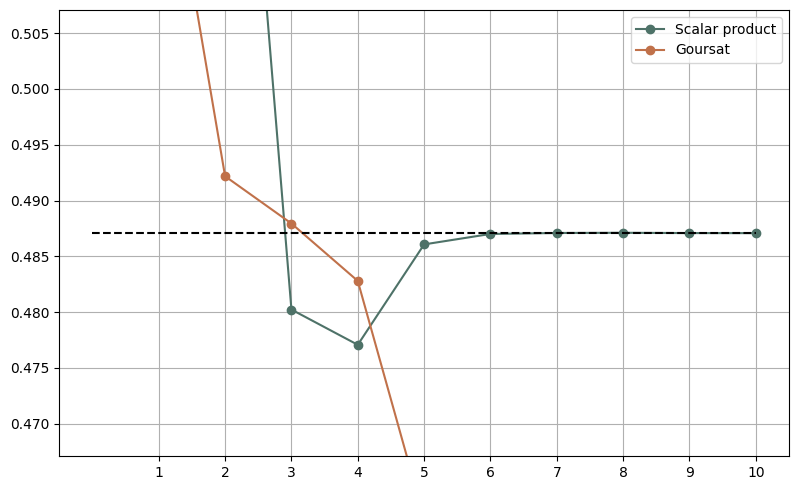

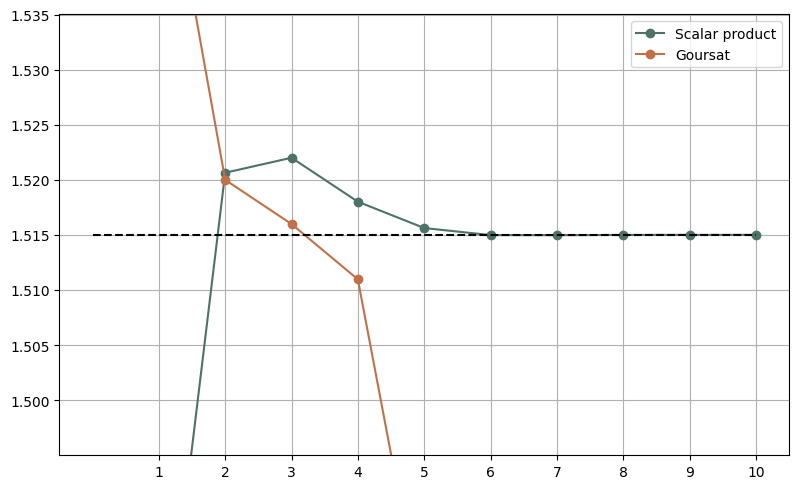

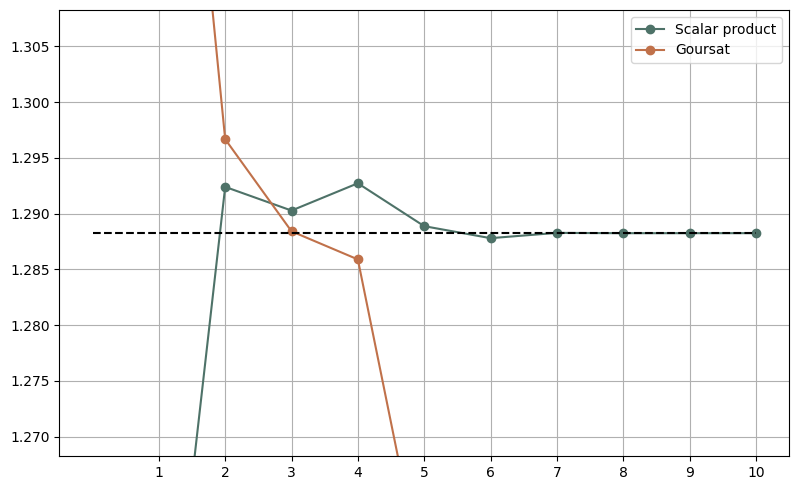

In [155]:
from signature.learning.signature_transform import SignatureTransform

# Simulating paths
# Synthetic data
batch, len_x, len_y, dim = 5, 50, 50, 2
# Use 'cuda', 'mps', or 'cpu' depending on available hardware
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
X = torch.rand((batch,len_x,dim), dtype=torch.float32, device=device) # shape (batch,len_x,dim)
Y = torch.rand((batch,len_y,dim), dtype=torch.float32, device=device) # shape (batch,len_y,dim)


# Linear kernel from signature
transformer = SignatureTransform(trunc=15)

K_scalar_arr = []
K_max_scalar_arr = []
for i in range(batch):
    X_sig = transformer.fit_transform(X.cpu().numpy()[i, :, :])[-1]
    Y_sig = transformer.fit_transform(Y.cpu().numpy()[i, :, :])[-1]

    K_scalar = []
    for trunc in range(1, 11):
        n_max = ta.number_of_words_up_to_trunc(trunc=trunc, dim=2)
        K_scalar.append(X_sig[:n_max] @ Y_sig[:n_max])
    K_scalar_arr.append(K_scalar)
    K_max_scalar_arr.append(X_sig @ Y_sig)

K_scalar_arr = np.array(K_scalar_arr)


# Linear kernel from Goursat's PDE
static_kernel = sigkernel.LinearKernel()

K_arr = []
dyadic_orders = [0, 1, 2, 3, 4, 5]
for dyadic_order in dyadic_orders:
    # Specify dyadic order for PDE solver (int > 0, default 0, the higher the more accurate but slower)

    # Specify maximum batch size of computation; if memory is a concern try reducing max_batch, default=100
    max_batch = 100

    # Initialize the corresponding signature kernel
    signature_kernel = sigkernel.SigKernel(static_kernel, dyadic_order)

    K = signature_kernel.compute_kernel(X,Y,max_batch)
    K_arr.append(K.cpu().numpy())

K_arr = np.array(K_arr).T


# Convergence
for i in range(batch):
    fig, ax = plt.subplots()
    plt.plot(range(1, 11), K_scalar_arr[i], "o-", label="Scalar product")

    plt.plot(dyadic_orders, K_arr[i], "o-", label="Goursat")

    final_K = K_max_scalar_arr[i]

    plt.hlines(final_K, 0, 10, ls="--", color="k")

    plt.ylim([final_K - 0.02, final_K + 0.02])
    plt.xticks(range(1, 11))
    plt.legend()

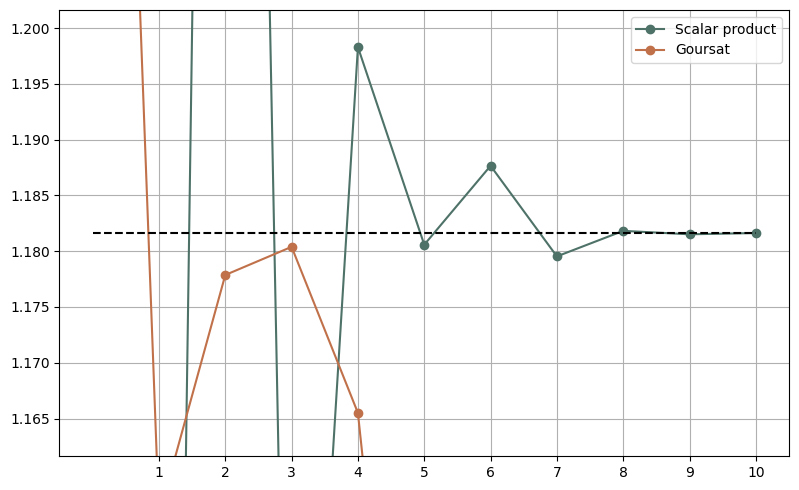

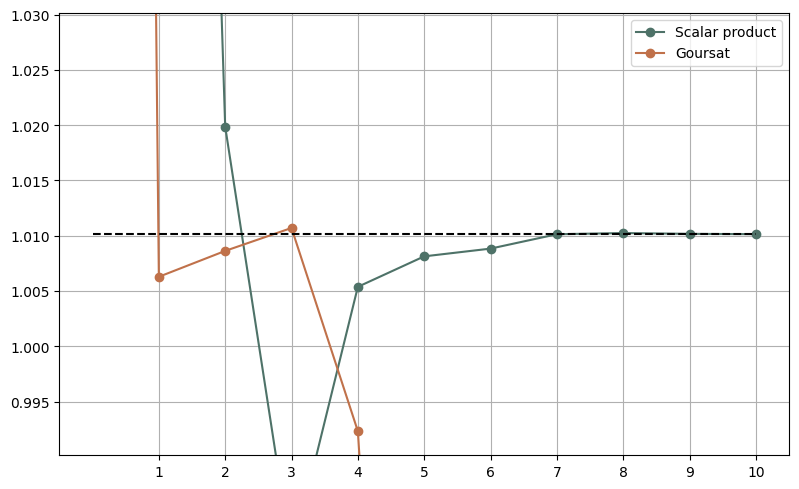

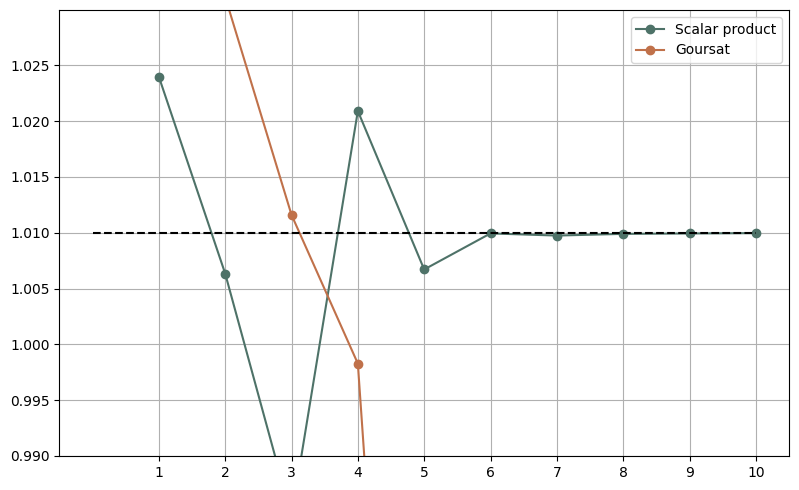

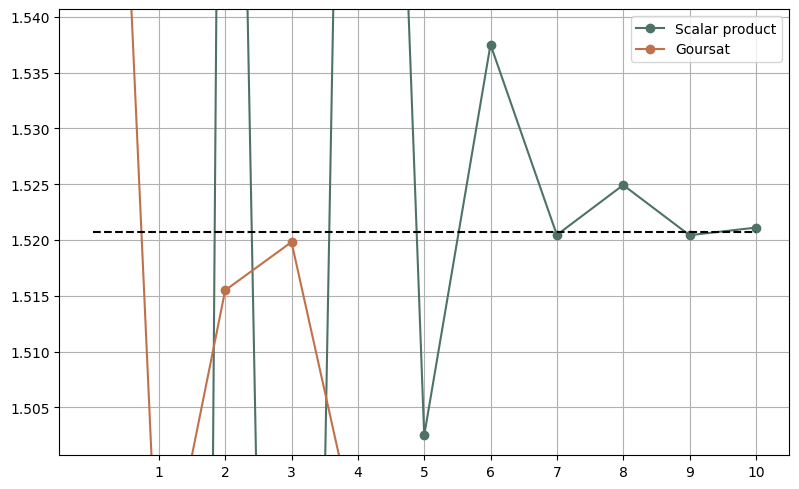

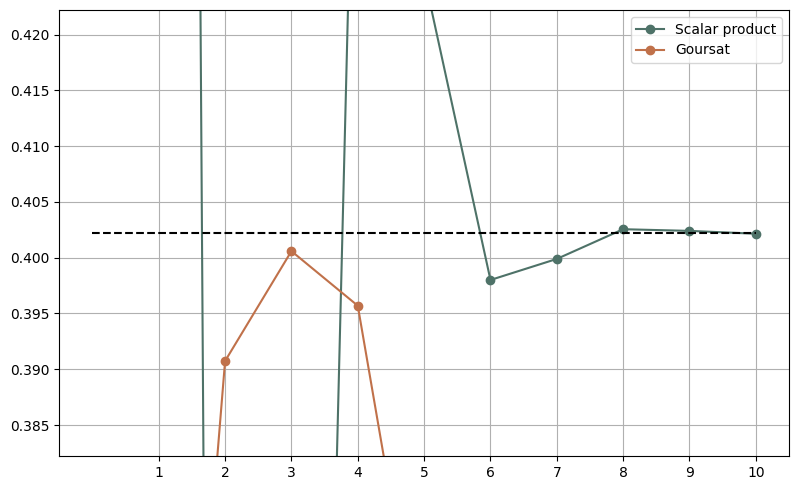

In [157]:
from signature.learning.signature_transform import SignatureTransform

# Simulating paths
# Synthetic data
batch, len_x, len_y, dim = 5, 100, 100, 2
# Use 'cuda', 'mps', or 'cpu' depending on available hardware
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
X = torch.rand((batch,len_x,dim), dtype=torch.float32, device=device) # shape (batch,len_x,dim)
Y = torch.rand((batch,len_y,dim), dtype=torch.float32, device=device) # shape (batch,len_y,dim)


# Linear kernel from signature
transformer = SignatureTransform(trunc=15)

K_scalar_arr = []
K_max_scalar_arr = []
for i in range(batch):
    X_sig = transformer.fit_transform(X.cpu().numpy()[i, :, :])[-1]
    Y_sig = transformer.fit_transform(Y.cpu().numpy()[i, :, :])[-1]

    K_scalar = []
    for trunc in range(1, 11):
        n_max = ta.number_of_words_up_to_trunc(trunc=trunc, dim=2)
        K_scalar.append(X_sig[:n_max] @ Y_sig[:n_max])
    K_scalar_arr.append(K_scalar)
    K_max_scalar_arr.append(X_sig @ Y_sig)

K_scalar_arr = np.array(K_scalar_arr)


# Linear kernel from Goursat's PDE
static_kernel = sigkernel.LinearKernel()

K_arr = []
dyadic_orders = [0, 1, 2, 3, 4, 5]
for dyadic_order in dyadic_orders:
    # Specify dyadic order for PDE solver (int > 0, default 0, the higher the more accurate but slower)

    # Specify maximum batch size of computation; if memory is a concern try reducing max_batch, default=100
    max_batch = 100

    # Initialize the corresponding signature kernel
    signature_kernel = sigkernel.SigKernel(static_kernel, dyadic_order)

    K = signature_kernel.compute_kernel(X,Y,max_batch)
    K_arr.append(K.cpu().numpy())

K_arr = np.array(K_arr).T


# Convergence
for i in range(batch):
    fig, ax = plt.subplots()
    plt.plot(range(1, 11), K_scalar_arr[i], "o-", label="Scalar product")

    plt.plot(dyadic_orders, K_arr[i], "o-", label="Goursat")

    final_K = K_max_scalar_arr[i]

    plt.hlines(final_K, 0, 10, ls="--", color="k")

    plt.ylim([final_K - 0.02, final_K + 0.02])
    plt.xticks(range(1, 11))
    plt.legend()

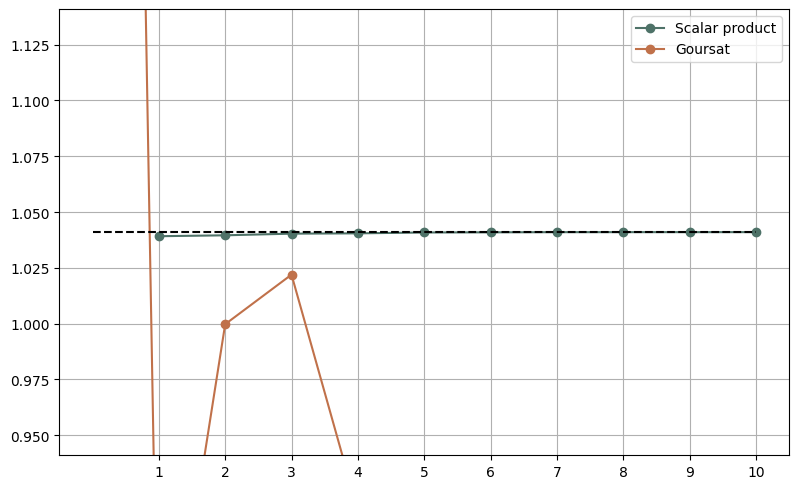

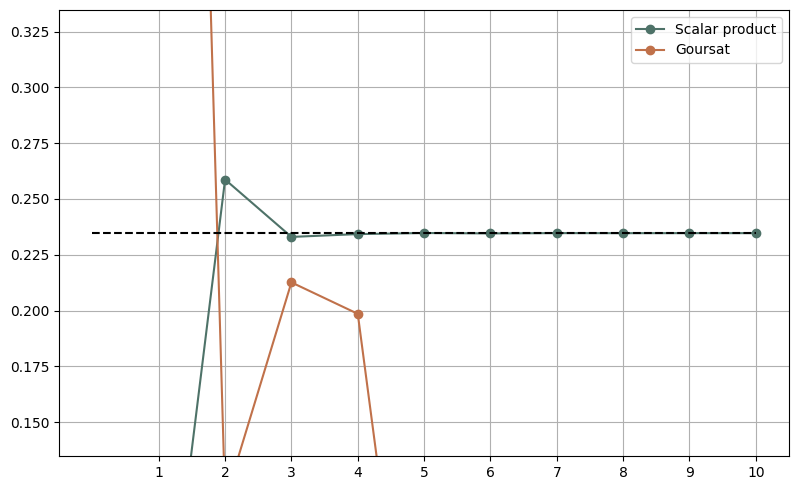

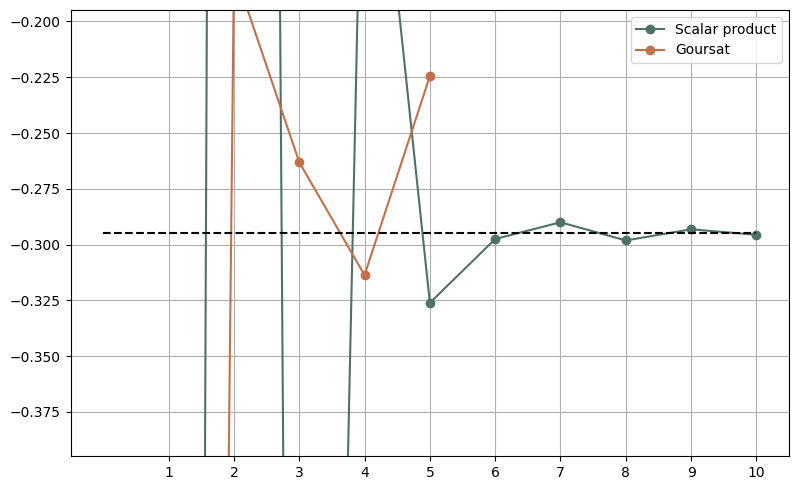

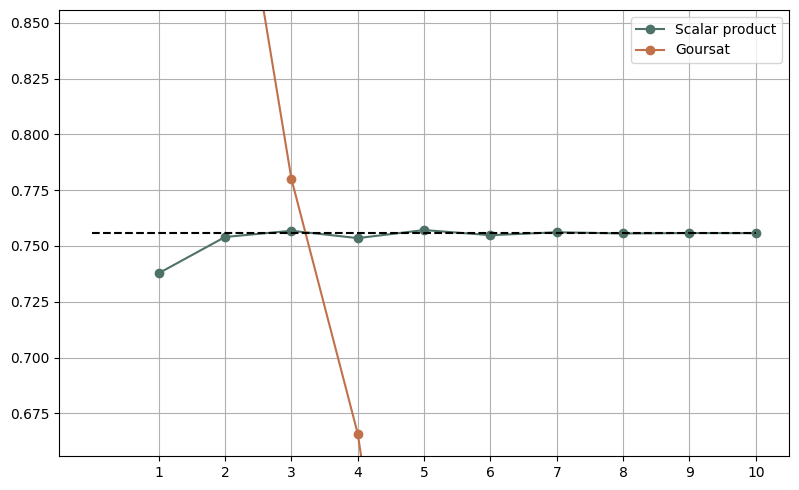

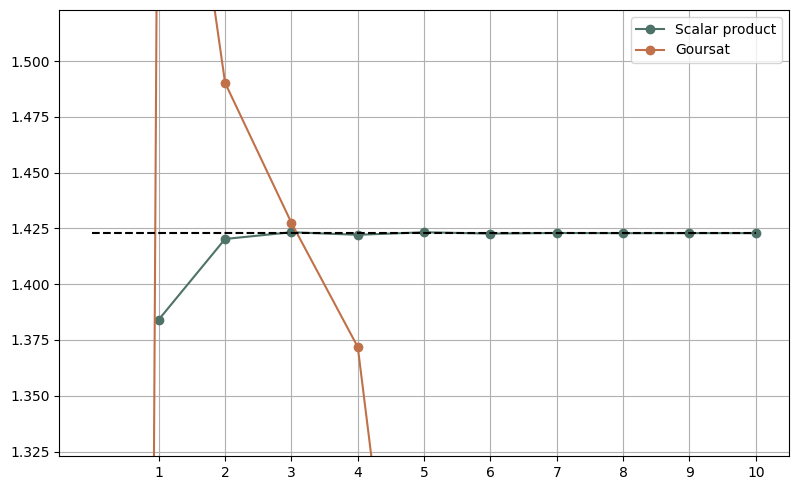

In [176]:

from signature.learning.signature_transform import SignatureTransform

# Simulating paths
# Synthetic data
batch, len_x, dim = 5, 150, 2
# Use 'cuda', 'mps', or 'cpu' depending on available hardware
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
X = torch.zeros((batch,len_x,dim), dtype=torch.float32, device=device)
Y = torch.zeros((batch,len_x,dim), dtype=torch.float32, device=device)


for i in range(batch):
    X[i, :, 0] = torch.asarray(t_grid[:len_x])
    X[i, :, 1] = torch.asarray(signal[i * len_x:(i + 1) * len_x])
    Y[i, :, 0] = torch.asarray(t_grid[:len_x])
    Y[i, :, 1] = torch.asarray(signal[(i + 1) * len_x:(i + 2) * len_x])
# X = torch.rand((batch,len_x,dim), dtype=torch.float32, device=device) # shape (batch,len_x,dim)
# Y = torch.rand((batch,len_y,dim), dtype=torch.float32, device=device) # shape (batch,len_y,dim)


# Linear kernel from signature
transformer = SignatureTransform(trunc=15)

K_scalar_arr = []
K_max_scalar_arr = []
for i in range(batch):
    X_sig = transformer.fit_transform(X.cpu().numpy()[i, :, :])[-1]
    Y_sig = transformer.fit_transform(Y.cpu().numpy()[i, :, :])[-1]

    K_scalar = []
    for trunc in range(1, 11):
        n_max = ta.number_of_words_up_to_trunc(trunc=trunc, dim=2)
        K_scalar.append(X_sig[:n_max] @ Y_sig[:n_max])
    K_scalar_arr.append(K_scalar)
    K_max_scalar_arr.append(X_sig @ Y_sig)

K_scalar_arr = np.array(K_scalar_arr)


# Linear kernel from Goursat's PDE
static_kernel = sigkernel.LinearKernel()

K_arr = []
dyadic_orders = [0, 1, 2, 3, 4, 5]
for dyadic_order in dyadic_orders:
    # Specify dyadic order for PDE solver (int > 0, default 0, the higher the more accurate but slower)

    # Specify maximum batch size of computation; if memory is a concern try reducing max_batch, default=100
    max_batch = 100

    # Initialize the corresponding signature kernel
    signature_kernel = sigkernel.SigKernel(static_kernel, dyadic_order)

    K = signature_kernel.compute_kernel(X,Y,max_batch)
    K_arr.append(K.cpu().numpy())

K_arr = np.array(K_arr).T


# Convergence
for i in range(batch):
    fig, ax = plt.subplots()
    plt.plot(range(1, 11), K_scalar_arr[i], "o-", label="Scalar product")

    plt.plot(dyadic_orders, K_arr[i], "o-", label="Goursat")

    final_K = K_max_scalar_arr[i]

    plt.hlines(final_K, 0, 10, ls="--", color="k")

    plt.ylim([final_K - 0.1, final_K + 0.1])
    plt.xticks(range(1, 11))
    plt.legend()

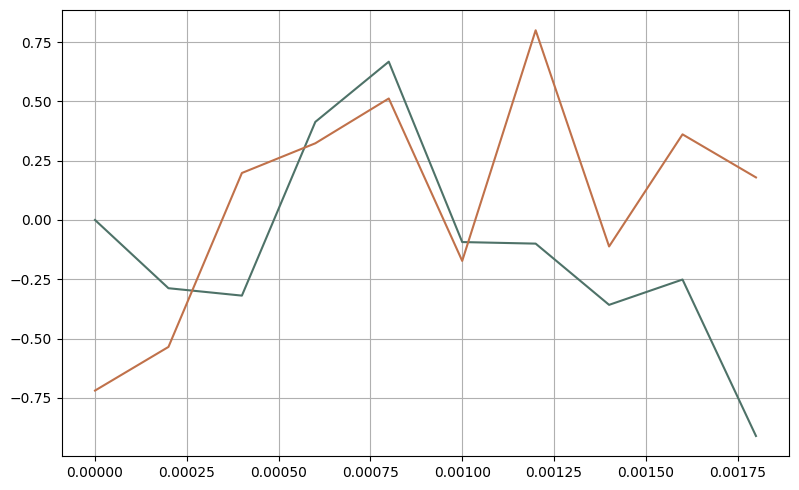

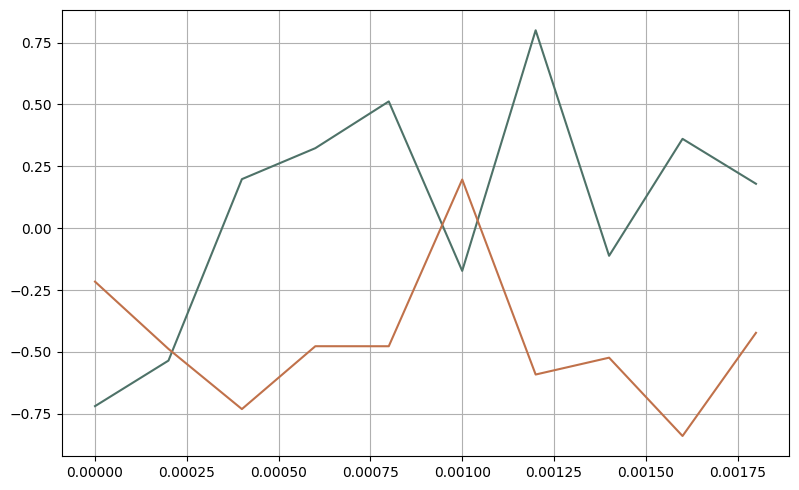

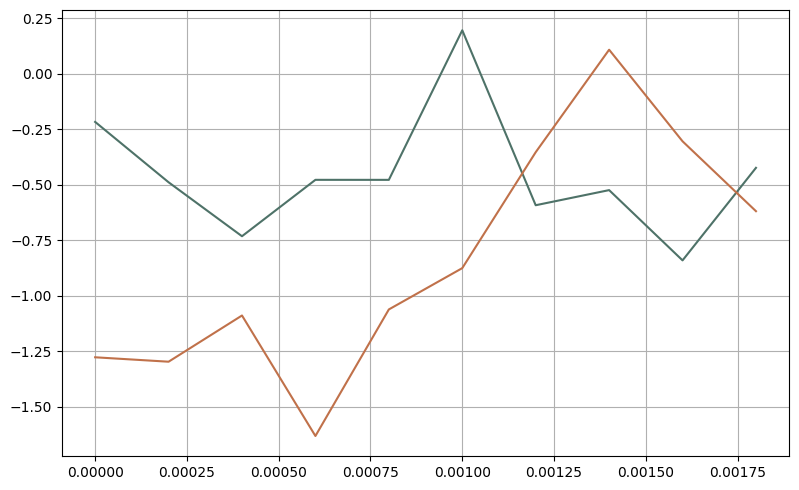

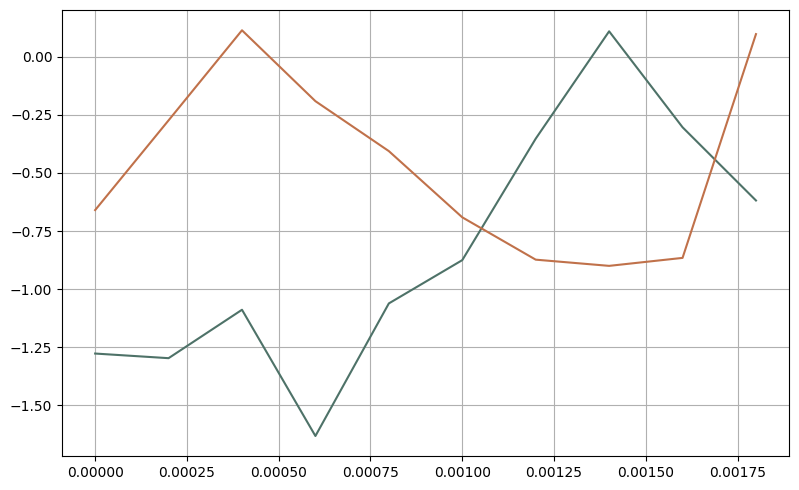

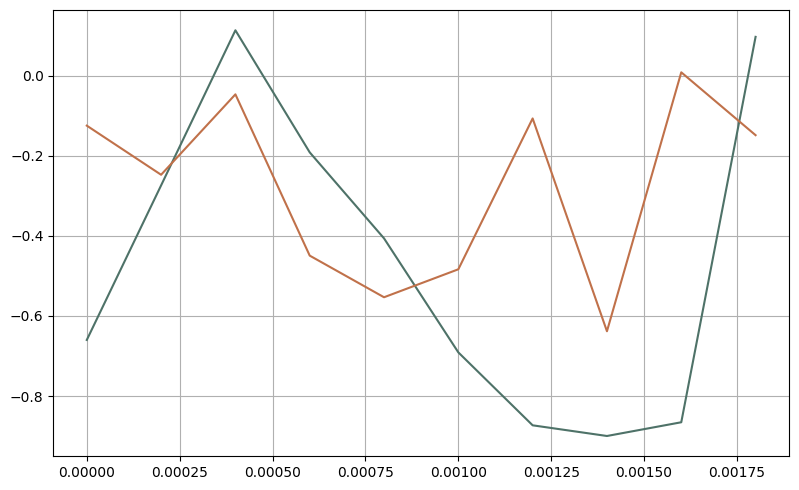

In [174]:
for i in range(batch):
    fig, ax = plt.subplots()
    plt.plot(X.cpu()[i, :, 0], X.cpu()[i, :, 1])
    plt.plot(Y.cpu()[i, :, 0], Y.cpu()[i, :, 1])